# Lab 1 — K-Means Baseline

**Day 05 · Unsupervised Learning · Cisco AI/ML Training**

---

## Goals

1. Build symbol-level features from NYSE daily candles.
2. Standardize numeric features before clustering.
3. Fit K-Means with a baseline `k=4` and inspect inertia.
4. Read cluster sizes to understand segment balance.

**Dataset:** `data/nyse/nyse_stocks.csv` (500 rows, 25 symbols)

## Baseline workflow

Daily rows -> aggregate to symbol features -> scale -> K-Means -> inspect counts and separation.

In [1]:
%matplotlib inline

from pathlib import Path

GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
elif (GH_ROOT.parent / "notebooks").is_dir() and (GH_ROOT.parents[1] / "requirements-student.txt").is_file():
    GH_ROOT = GH_ROOT.parents[1]
else:
    for parent in [GH_ROOT, *GH_ROOT.parents]:
        if (parent / "requirements-student.txt").is_file():
            GH_ROOT = parent
            break

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

FEATURE_COLUMNS = ["avg_close", "volatility", "avg_volume", "avg_range"]

nyse = pd.read_csv(GH_ROOT / "data" / "nyse" / "nyse_stocks.csv", parse_dates=["date"])
print(f"dataset path: {GH_ROOT / 'data' / 'nyse' / 'nyse_stocks.csv'}")
print(f"daily rows: {len(nyse)}")
print(f"symbols: {nyse['symbol'].nunique()}")
display(nyse.head(3))


dataset path: C:\25-Trainings\2-Confirmed\10-June-26-AI-ML-Cisco\GH\data\nyse\nyse_stocks.csv
daily rows: 500
symbols: 25


,symbol,date,open,high,low,close,volume
0,AAPL,2024-01-02,184.56,186.03,182.98,184.46,35160981
1,MSFT,2024-01-03,214.92,215.58,210.13,212.00,17544708
2,GOOGL,2024-01-04,125.60,126.04,125.21,125.40,22127720


## Build symbol features

In [2]:

nyse["range"] = nyse["high"] - nyse["low"]
features = (
    nyse.groupby("symbol")
    .agg(
        avg_close=("close", "mean"),
        volatility=("close", "std"),
        avg_volume=("volume", "mean"),
        avg_range=("range", "mean"),
    )
    .reset_index()
)
features["volatility"] = features["volatility"].fillna(0.0)

print(f"symbols clustered: {len(features)}")
display(features.head(5))


symbols clustered: 25


,symbol,avg_close,volatility,avg_volume,avg_range
0,AAPL,186.8825,2.233211,25855466.60,2.5030
1,AMZN,52.7650,2.605893,24106218.45,2.3970
2,BAC,130.1855,2.417812,27648336.50,2.7290
3,CSCO,164.6195,2.529372,24289015.25,2.9920
4,DIS,203.2860,2.494703,27921575.55,3.1535


## Inspect descriptive statistics

In [3]:
display(features[FEATURE_COLUMNS].describe().round(3))
print("Any missing values by column:")
print(features[FEATURE_COLUMNS].isna().sum())


,avg_close,volatility,avg_volume,avg_range
count,25.000,25.000,2.500000e+01,25.000
mean,137.957,2.575,2.517616e+07,2.869
std,62.979,0.363,2.916751e+06,0.264
min,52.765,1.630,1.922443e+07,2.397
25%,86.881,2.337,2.388599e+07,2.692
50%,130.185,2.562,2.538231e+07,2.906
75%,186.882,2.841,2.764834e+07,3.023
max,247.818,3.309,2.995472e+07,3.352


Any missing values by column:
avg_close     0
volatility    0
avg_volume    0
avg_range     0
dtype: int64


## Prepare matrix and scale

In [4]:
X = features[FEATURE_COLUMNS]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(X_scaled, columns=FEATURE_COLUMNS)
display(pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "raw": X.iloc[0].round(2).values,
    "scaled": scaled_df.iloc[0].round(2).values,
}))


,feature,raw,scaled
0,avg_close,186.88,0.79
1,volatility,2.23,-0.96
2,avg_volume,25855466.60,0.24
3,avg_range,2.50,-1.42


## Fit baseline K-Means

In [5]:
k = 4
model = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = model.fit_predict(X_scaled)

features = features.copy()
features["cluster"] = labels

print("Lab 1 — K-Means baseline")
print(f"features: {FEATURE_COLUMNS}")
print(f"k: {k}")
print(f"inertia: {model.inertia_:.4f}")

unique, counts = np.unique(labels, return_counts=True)
cluster_counts = dict(zip(unique.tolist(), counts.tolist()))
print(f"cluster counts: {cluster_counts}")


Lab 1 — K-Means baseline
features: ['avg_close', 'volatility', 'avg_volume', 'avg_range']
k: 4
inertia: 45.8634
cluster counts: {0: 8, 1: 9, 2: 7, 3: 1}


## Cluster centers in scaled space

In [6]:
centers_scaled = pd.DataFrame(model.cluster_centers_, columns=FEATURE_COLUMNS)
display(centers_scaled.round(3))


,avg_close,volatility,avg_volume,avg_range
0,1.055,0.403,-0.432,0.662
1,-0.397,-0.723,0.547,-0.661
2,-0.914,0.848,0.082,0.253
3,1.533,-2.655,-2.043,-1.116


## Cluster centers in original units

In [7]:
centers_raw = pd.DataFrame(
    scaler.inverse_transform(model.cluster_centers_),
    columns=FEATURE_COLUMNS,
)
display(centers_raw.round(2))


,avg_close,volatility,avg_volume,avg_range
0,203.03,2.72,23941634.18,3.04
1,113.49,2.32,26739334.61,2.70
2,81.54,2.88,25411128.95,2.93
3,232.55,1.63,19338890.65,2.58


## Sorted cluster membership

In [8]:
display(
    features[["symbol", "avg_close", "volatility", "cluster"]]
    .sort_values(["cluster", "symbol"])
    .round(2)
)


,symbol,avg_close,volatility,cluster
3,CSCO,164.62,2.53,0
4,DIS,203.29,2.49,0
13,MSFT,215.09,3.11,0
14,NFLX,220.97,2.68,0
15,NVDA,171.25,2.49,0
19,TSLA,230.07,2.86,0
21,V,247.82,2.81,0
22,VZ,171.15,2.78,0
0,AAPL,186.88,2.23,1
1,AMZN,52.76,2.61,1


## Visual cluster scatter

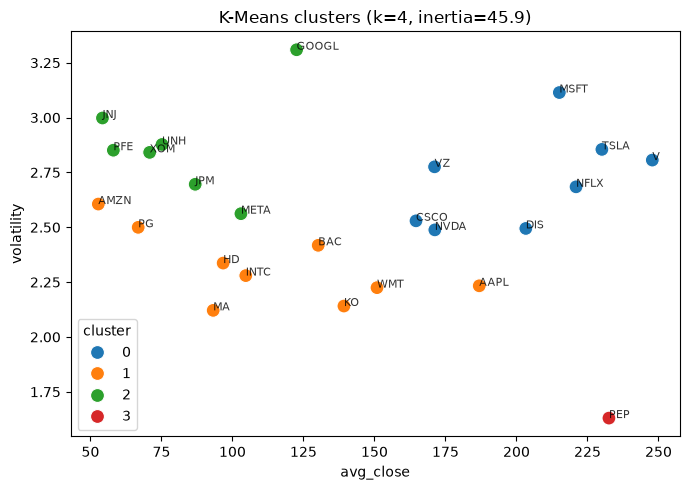

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=features,
    x="avg_close",
    y="volatility",
    hue="cluster",
    palette="tab10",
    s=100,
    ax=ax,
)
for _, row in features.iterrows():
    ax.annotate(row["symbol"], (row["avg_close"], row["volatility"]), fontsize=8, alpha=0.8)
ax.set_title(f"K-Means clusters (k={k}, inertia={model.inertia_:.1f})")
plt.tight_layout()
plt.show()


## Compare with k=3

In [10]:
model_k3 = KMeans(n_clusters=3, random_state=42, n_init=10)
model_k3.fit_predict(X_scaled)

compare_k = pd.DataFrame({
    "k": [3, 4],
    "inertia": [model_k3.inertia_, model.inertia_],
})
display(compare_k.round(4))
print("Lower inertia with more clusters — Lab 2 finds the best k via the elbow method.")


,k,inertia
0,3,57.1748
1,4,45.8634


Lower inertia with more clusters — Lab 2 finds the best k via the elbow method.


### Guided mini-check 1

How many symbols land in each cluster when sorted by label?

In [11]:
print(features['cluster'].value_counts().sort_index())

cluster
0    8
1    9
2    7
3    1
Name: count, dtype: int64


### Guided mini-check 2

Which symbol has the highest average close?

In [12]:
display(features.nlargest(3, 'avg_close')[['symbol', 'avg_close', 'cluster']].round(2))

,symbol,avg_close,cluster
21,V,247.82,0
16,PEP,232.55,3
19,TSLA,230.07,0


### Guided mini-check 3

Which symbol has the highest volatility?

In [13]:
display(features.nlargest(3, 'volatility')[['symbol', 'volatility', 'cluster']].round(3))

,symbol,volatility,cluster
5,GOOGL,3.309,2
13,MSFT,3.114,0
8,JNJ,2.998,2


### Guided mini-check 4

Do scaled features have mean ~0?

In [14]:
print(pd.DataFrame(X_scaled, columns=FEATURE_COLUMNS).mean().round(6))

avg_close    -0.0
volatility    0.0
avg_volume    0.0
avg_range    -0.0
dtype: float64


### Guided mini-check 5

Do scaled features have std ~1?

In [15]:
print(pd.DataFrame(X_scaled, columns=FEATURE_COLUMNS).std(ddof=0).round(6))

avg_close     1.0
volatility    1.0
avg_volume    1.0
avg_range     1.0
dtype: float64


### Guided mini-check 6

Review within-cluster average features.

In [16]:
display(features.groupby('cluster')[FEATURE_COLUMNS].mean().round(2))

,avg_close,volatility,avg_volume,avg_range
cluster,,,,
0,203.03,2.72,23941634.18,3.04
1,113.49,2.32,26739334.61,2.70
2,81.54,2.88,25411128.95,2.93
3,232.55,1.63,19338890.65,2.58


### Guided mini-check 7

Compare cluster median volatility.

In [17]:
display(features.groupby('cluster')['volatility'].median().round(3))

cluster
0    2.730
1    2.280
2    2.851
3    1.630
Name: volatility, dtype: float64

### Guided mini-check 8

Check symbol order within one cluster.

In [18]:
display(features.loc[features['cluster']==0, ['symbol','avg_close']].sort_values('symbol'))

,symbol,avg_close
3,CSCO,164.6195
4,DIS,203.2860
13,MSFT,215.0860
14,NFLX,220.9700
15,NVDA,171.2490
19,TSLA,230.0730
21,V,247.8180
22,VZ,171.1505


### Guided mini-check 9

Inspect farthest symbols by avg_range.

In [19]:
display(features.nlargest(5, 'avg_range')[['symbol','avg_range','cluster']].round(2))

,symbol,avg_range,cluster
13,MSFT,3.35,0
20,UNH,3.29,2
4,DIS,3.15,0
19,TSLA,3.15,0
22,VZ,3.11,0


### Guided mini-check 10

Summarize inertia and cluster count.

In [20]:
print({'k': k, 'inertia': round(model.inertia_, 4), 'clusters': len(cluster_counts)})

{'k': 4, 'inertia': 45.8634, 'clusters': 4}


### Guided mini-check 11

What fraction of symbols are in cluster 1?

In [21]:
print(round((features['cluster']==1).mean(), 3))

0.36


### Guided mini-check 12

Show top-2 avg_volume per cluster.

In [22]:
display(features.sort_values(['cluster','avg_volume'], ascending=[True, False]).groupby('cluster').head(2)[['symbol','cluster','avg_volume']].round(2))

,symbol,cluster,avg_volume
4,DIS,0,27921575.55
19,TSLA,0,26681421.60
23,WMT,1,29954724.30
6,HD,1,28459902.90
5,GOOGL,2,29063539.55
9,JPM,2,28041458.25
16,PEP,3,19338890.65


### Guided mini-check 13

Cross-check feature matrix shape.

In [23]:
print('X shape:', X.shape, '| X_scaled shape:', X_scaled.shape)

X shape: (25, 4) | X_scaled shape: (25, 4)


### Guided mini-check 14

Compare mean avg_close by cluster.

In [24]:
print(features.groupby('cluster')['avg_close'].mean().round(2).to_dict())

{0: 203.03, 1: 113.49, 2: 81.54, 3: 232.55}

### Guided mini-check 15

Inspect one symbol end-to-end row.

In [25]:
display(features.loc[features['symbol']=='MSFT', ['symbol', *FEATURE_COLUMNS, 'cluster']].round(2))

,symbol,avg_close,volatility,avg_volume,avg_range,cluster
13,MSFT,215.09,3.11,22506663.85,3.35,0


### Guided mini-check 16

Check whether any two symbols share identical feature rows.

In [26]:
print(features[FEATURE_COLUMNS].duplicated().sum())

0


### Guided mini-check 17

List symbols per cluster quickly.

In [27]:
print(features.groupby('cluster')['symbol'].apply(list).to_dict())

{0: ['CSCO', 'DIS', 'MSFT', 'NFLX', 'NVDA', 'TSLA', 'V', 'VZ'], 1: ['AAPL', 'AMZN', 'BAC', 'HD', 'INTC', 'KO', 'MA', 'PG', 'WMT'], 2: ['GOOGL', 'JNJ', 'JPM', 'META', 'PFE', 'UNH', 'XOM'], 3: ['PEP']}


### Guided mini-check 18

Sort by volatility and review first 8 rows.

In [28]:
display(features[['symbol','volatility','cluster']].sort_values('volatility').head(8).round(3))

,symbol,volatility,cluster
16,PEP,1.630,3
11,MA,2.121,1
10,KO,2.141,1
23,WMT,2.225,1
0,AAPL,2.233,1
7,INTC,2.280,1
6,HD,2.337,1
2,BAC,2.418,1


### Guided mini-check 19

Verify no null in model input.

In [29]:
print(pd.DataFrame(X_scaled, columns=FEATURE_COLUMNS).isna().sum().to_dict())

{'avg_close': 0, 'volatility': 0, 'avg_volume': 0, 'avg_range': 0}


### Guided mini-check 20

Re-state baseline takeaway in code output.

In [30]:
print('Baseline k=4 creates four compact groups with one singleton cluster.')

Baseline k=4 creates four compact groups with one singleton cluster.


## Final checkpoint

In [31]:
assert len(features) == 25
assert k == 4
assert abs(model.inertia_ - 45.8634) < 0.1
assert cluster_counts == {0: 8, 1: 9, 2: 7, 3: 1}
print("Numbers match — you're good.")



Numbers match — you're good.


## Reflection

How does changing `k` affect inertia and interpretability trade-offs?